# Adiantando a saida

In [6]:
import pandas as pd
import numpy as np

# Carrega e prepara os dados
TrainData = pd.read_csv("../Dados/DataSpline.csv")
TrainData.index = (np.arange(0, len(TrainData), 1).astype(float) * 0.07).round(5)

TrainData["theta"] = TrainData["theta(Wd,We)"]
TrainData["theta(Wd,We)"] = TrainData["theta(Wd,We)"].shift(1)
TrainData["Wd-We"] = TrainData["Wd"] - TrainData["We"]

TrainData = TrainData.iloc[1:]

In [7]:
TestData = pd.read_csv("../Dados/DataSpline2.csv")
TestData.index = (np.arange(0, len(TestData), 1).astype(float) * 0.07).round(5)

TestData["theta"] = TestData["theta(Wd,We)"]
TestData["theta(Wd,We)"] = TestData["theta(Wd,We)"].shift(1)
TestData["Wd-We"] = TestData["Wd"] - TestData["We"]

TestData = TestData.iloc[1:]

In [8]:
import matplotlib.pyplot as plt

PREDICTORS = ["Wd-We"]
TARGET = ["theta(Wd,We)", "theta"]

def PlotTimeSeries(df, img_name="data.svg", PlotOut=True):    
    # Paletas manuais para preditores e alvos
    predictor_colors = plt.cm.tab10.colors
    target_colors = plt.cm.Set2.colors

    fig, ax1 = plt.subplots(figsize=(12, 6))

    # Plot preditores no eixo esquerdo
    for i, preds in enumerate(PREDICTORS):
        ax1.plot(df.index, df[preds], marker="o", label=preds,
                 color=predictor_colors[i % len(predictor_colors)],
                 linewidth=2)

    ax1.set_xlabel("Tempo (s) - Período de amostragem (T=0.07 s)", fontsize=12)
    ax1.set_ylabel("Velocidade Angular", fontsize=12, color="black")
    ax1.tick_params(axis='y', labelcolor="black")

    # Plot alvos no eixo direito, se ativado
    if PlotOut:
        ax2 = ax1.twinx()
        for i, target in enumerate(TARGET):
            ax2.plot(df.index, df[target], marker="s", linestyle="--", label=target,
                     color=target_colors[i % len(target_colors)],
                     linewidth=2)
        ax2.set_ylabel("Posição Angular", fontsize=12, color="gray")
        ax2.tick_params(axis='y', labelcolor="gray")

    # Legendas separadas
    leg1 = ax1.legend(loc="upper left", title="Preditores")
    ax1.add_artist(leg1)  # Necessário para manter ambas visíveis
    if PlotOut:
        ax2.legend(loc="upper right", title="Alvos")

    # Título
    plt.title("Posição angular em função da velocidade nas rodas", fontsize=14)
    
    # Layout e exportação
    plt.tight_layout()
    plt.savefig(f"content/figs/{img_name}", format="svg", dpi=600)
    plt.show()


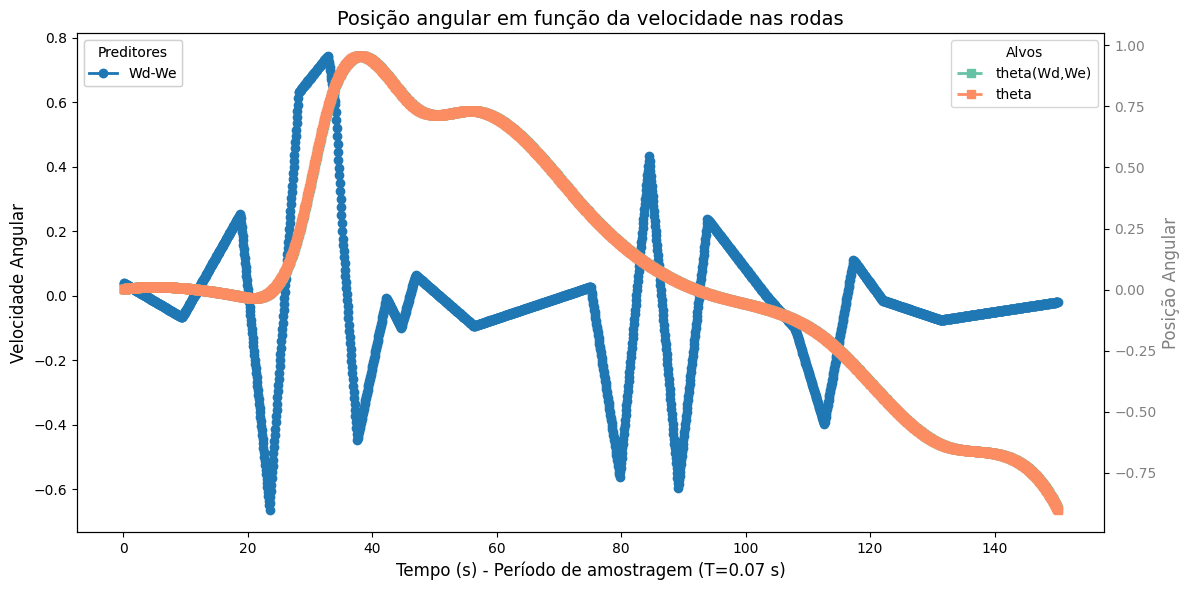

In [9]:
PlotTimeSeries(TrainData)

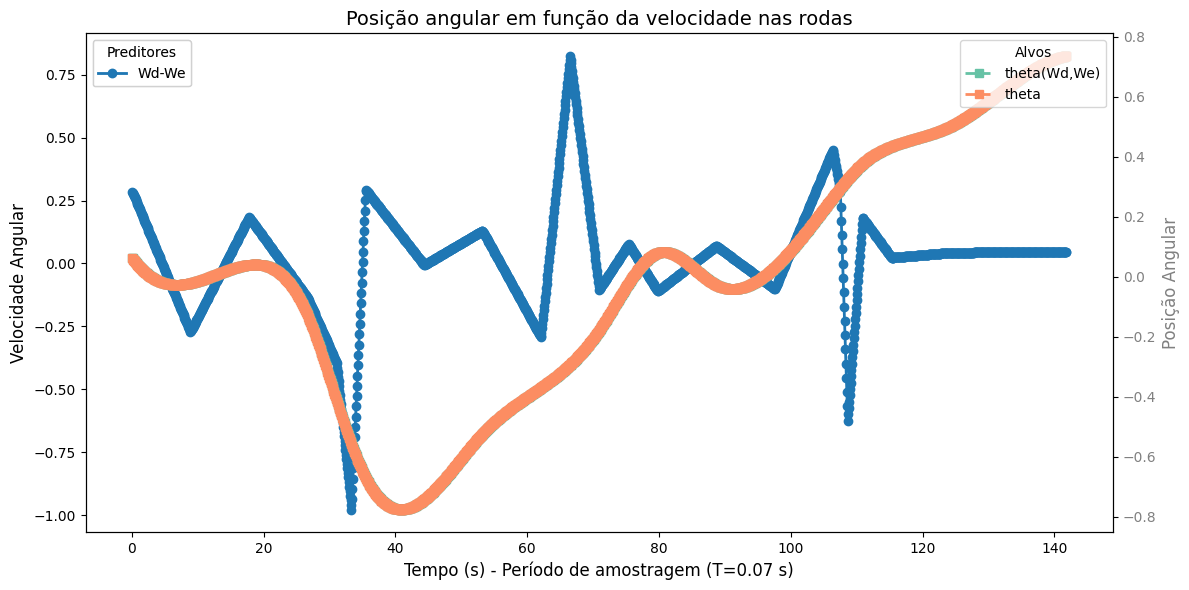

In [10]:
PlotTimeSeries(TestData)

In [11]:
from pykrige.ok import OrdinaryKriging
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_percentage_error, root_mean_squared_error
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

VARIOGRAMS = ["gaussian", 'exponential', "spherical", "hole-effect", "power", "linear"]
PREDICTORS = ["Wd-We", "theta"]
TARGET = "theta(Wd,We)"

class Kriging2D:

    def __init__(self, TrainData, TestData):        

        self.train_samples_x = np.array(TrainData[PREDICTORS])
        self.train_samples_y = np.array(TrainData[TARGET])
        
        self.test_samples_x = np.array(TestData[PREDICTORS])
        self.test_samples_y = np.array(TestData[TARGET])
        
        self.train_time = TrainData.head(np.size(self.train_samples_y)).index
        self.test_time = TestData.tail(np.size(self.test_samples_y)).index

        self.kriging_model = None

    def BuildModel(self, VariogramType):
        self.kriging_model = OrdinaryKriging(
            self.train_samples_x[:, 0],  # Wd-We
            self.train_samples_x[:, 1],  # theta
            self.train_samples_y,
            variogram_model=VariogramType
        )

    def ComputeMetrics(self):
        self.train_pred, _ = self.kriging_model.execute(
            'points',
            self.train_samples_x[:, 0],
            self.train_samples_x[:, 1]
        )

        self.test_pred, _ = self.kriging_model.execute(
            'points',
            self.test_samples_x[:, 0],
            self.test_samples_x[:, 1]
        )

        return {
            'r2_training': r2_score(self.train_samples_y, self.train_pred),
            'mse_training': mean_squared_error(self.train_samples_y, self.train_pred),
            'mape_training': mean_absolute_percentage_error(self.train_samples_y, self.train_pred),
            'rmse_training': root_mean_squared_error(self.train_samples_y, self.train_pred),

            'r2_test': r2_score(self.test_samples_y, self.test_pred),
            'mse_test': mean_squared_error(self.test_samples_y, self.test_pred),
            'mape_test': mean_absolute_percentage_error(self.test_samples_y, self.test_pred),
            'rmse_test': root_mean_squared_error(self.test_samples_y, self.test_pred),
        }

    def PlotOut(self, variogram):
        # Cores diferentes para cada linha
        colors = plt.cm.tab10.colors  # Paleta com 10 cores distintas

        # Criação da figura com dois subplots lado a lado
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), sharey=False)

        # Plot Treinamento
        ax1.plot(self.train_time, self.train_pred, marker="o", linewidth=2,
                label="train_pred", color=colors[0])
        ax1.plot(self.train_time, self.train_samples_y, marker="o", linewidth=2,
                label="train_orig", color=colors[1])
        ax1.set_title("Dados de Treinamento", fontsize=13)
        ax1.set_xlabel("Tempo (s)", fontsize=12)
        ax1.set_ylabel("Velocidade Angular", fontsize=12)
        ax1.legend()
        ax1.grid(True)

        # Plot Teste
        ax2.plot(self.test_time, self.test_pred, marker="o", linewidth=2,
                label="test_pred", color=colors[2])
        ax2.plot(self.test_time, self.test_samples_y, marker="o", linewidth=2,
                label="test_orig", color=colors[3])
        ax2.set_title("Dados de Teste", fontsize=13)
        ax2.set_xlabel("Tempo (s)", fontsize=12)
        ax2.legend()
        ax2.grid(True)

        # Título geral
        fig.suptitle(f"Resultados do modelo Kriging 2D: {variogram}", fontsize=15)

        # Salvando a figura
        plt.tight_layout(rect=[0, 0.03, 1, 0.95])  # Ajusta espaço para o suptitle
        plt.savefig(f"content/figs/{variogram}.svg", format="svg", dpi=600)

        # Exibe o gráfico
        plt.show()

    def EvalModel(self, excel_path):
        self.models = {}
        with pd.ExcelWriter(excel_path, engine='openpyxl') as writer:
            for variogram in VARIOGRAMS:
                self.BuildModel(VariogramType=variogram)
                metrics = self.ComputeMetrics()
                self.models[variogram] = self.kriging_model

                display(metrics)
                df = pd.DataFrame([metrics])
                df.to_excel(writer, sheet_name=variogram, index=False)
                self.PlotOut(variogram)

{'r2_training': -1896.0242040935855,
 'mse_training': 456.8023264259097,
 'mape_training': 440.86025910647544,
 'rmse_training': 21.37293443647619,
 'r2_test': -73427.23325849489,
 'mse_test': 12090.67341919551,
 'mape_test': 353.5946876659316,
 'rmse_test': 109.95759827858878}

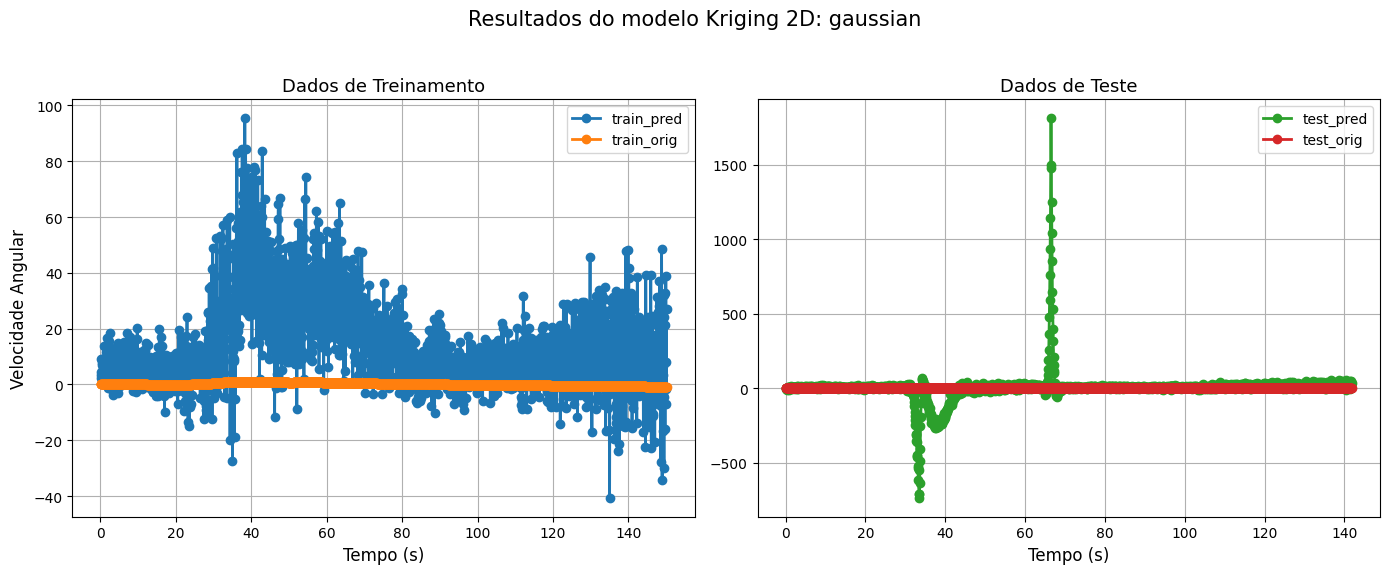

{'r2_training': 1.0,
 'mse_training': 4.791905474772092e-25,
 'mape_training': 3.3085030339063316e-11,
 'rmse_training': 6.922359044987548e-13,
 'r2_test': 0.96032349071072,
 'mse_test': 0.006533123499534328,
 'mape_test': 0.108944959986798,
 'rmse_test': 0.08082773966612161}

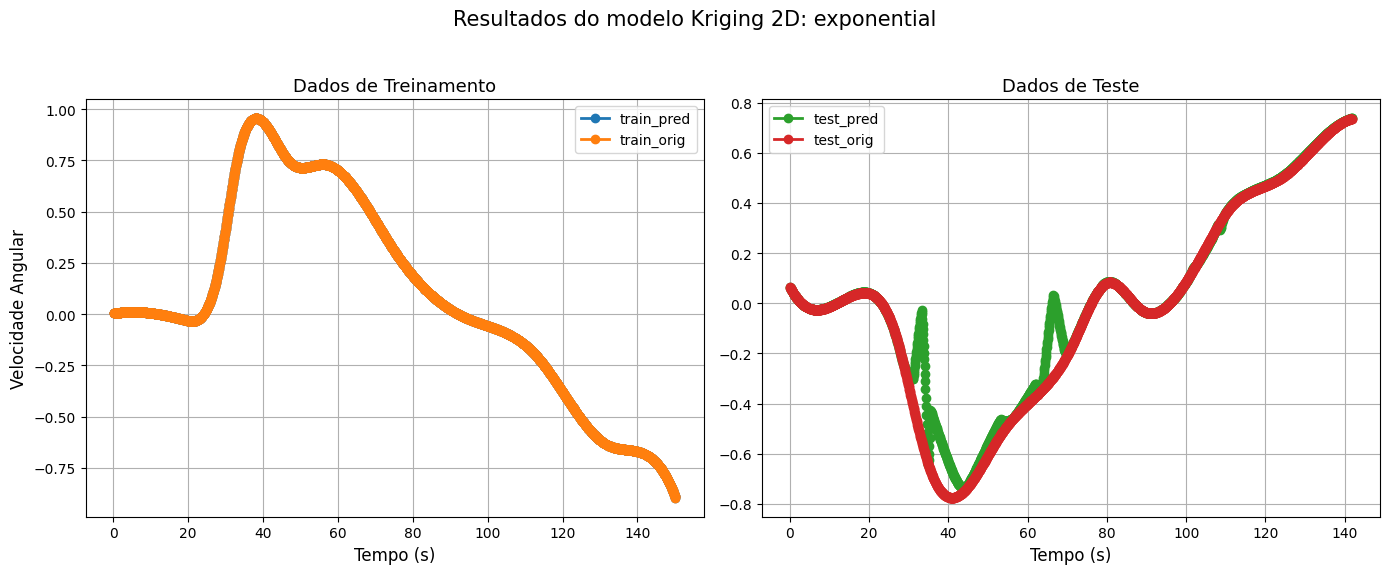

{'r2_training': 1.0,
 'mse_training': 1.2798509565761732e-24,
 'mape_training': 4.2068338972882384e-11,
 'rmse_training': 1.1313049794711296e-12,
 'r2_test': 0.9799460673825205,
 'mse_test': 0.0033020752275889245,
 'mape_test': 0.08419849960716481,
 'rmse_test': 0.05746368616429792}

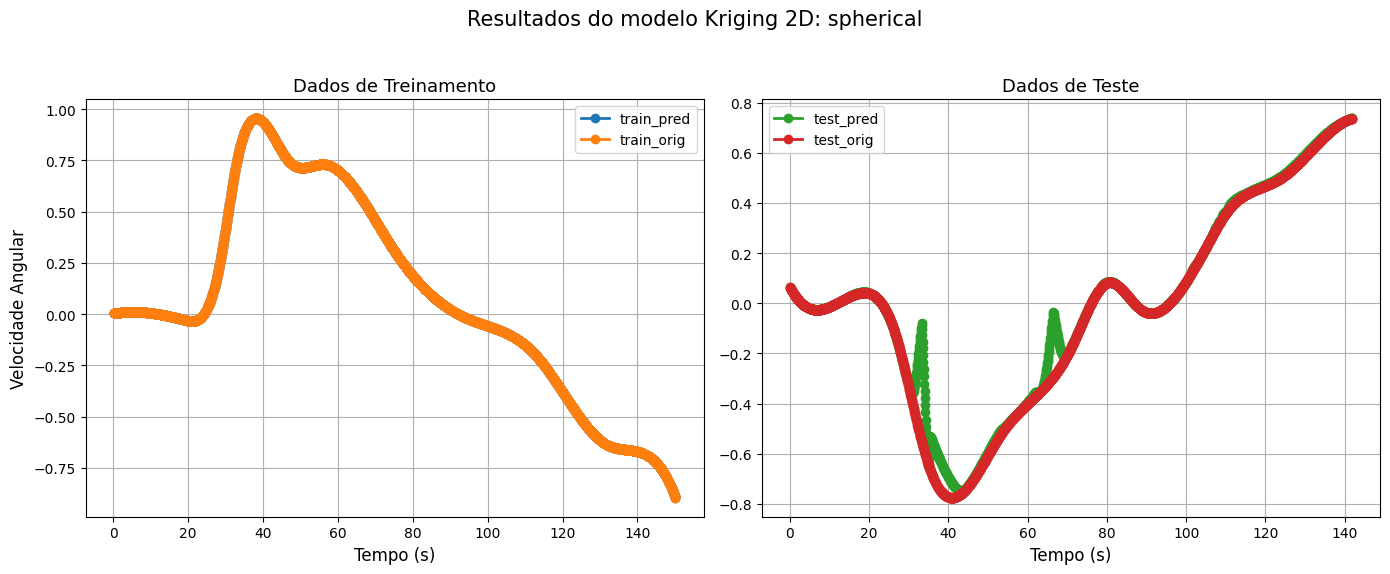

{'r2_training': 1.0,
 'mse_training': 4.206374340171254e-25,
 'mape_training': 2.8304825287998096e-11,
 'rmse_training': 6.485656744055496e-13,
 'r2_test': 0.8586620574650461,
 'mse_test': 0.02327266814271948,
 'mape_test': 0.17353638633215482,
 'rmse_test': 0.15255382047893615}

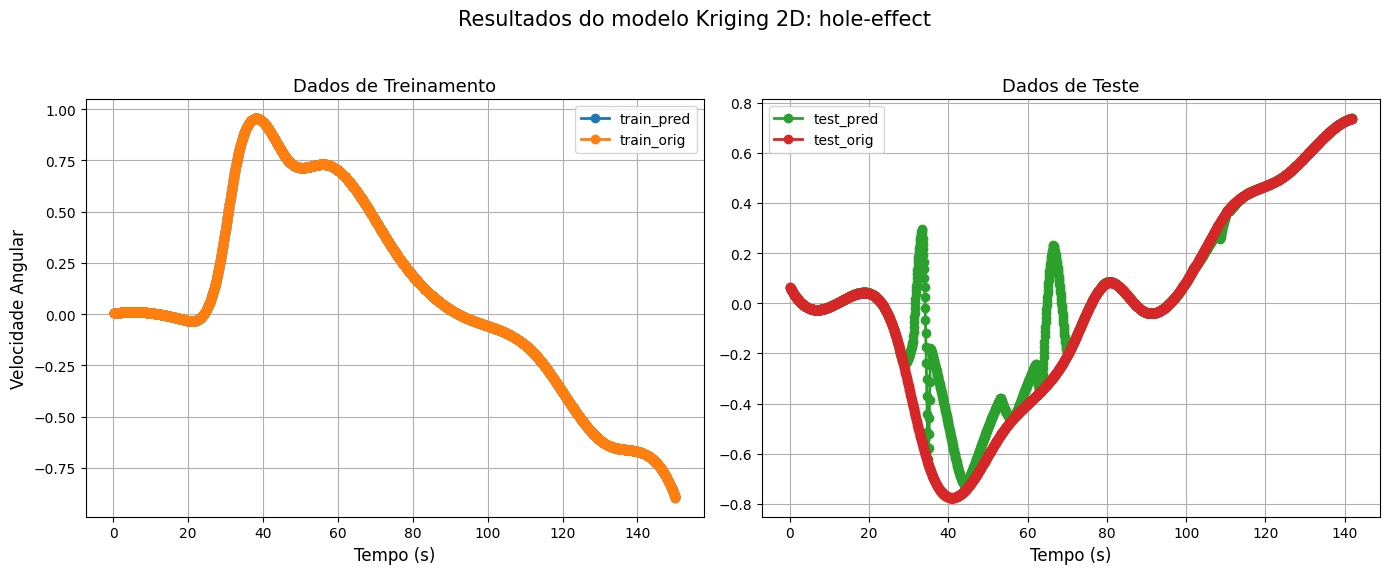

{'r2_training': 0.9999999996119735,
 'mse_training': 9.343655770505802e-11,
 'mape_training': 0.00022911199596658362,
 'rmse_training': 9.666258723262998e-06,
 'r2_test': 0.9999250836640439,
 'mse_test': 1.2335704014825583e-05,
 'mape_test': 0.06064400080190788,
 'rmse_test': 0.0035122220907604323}

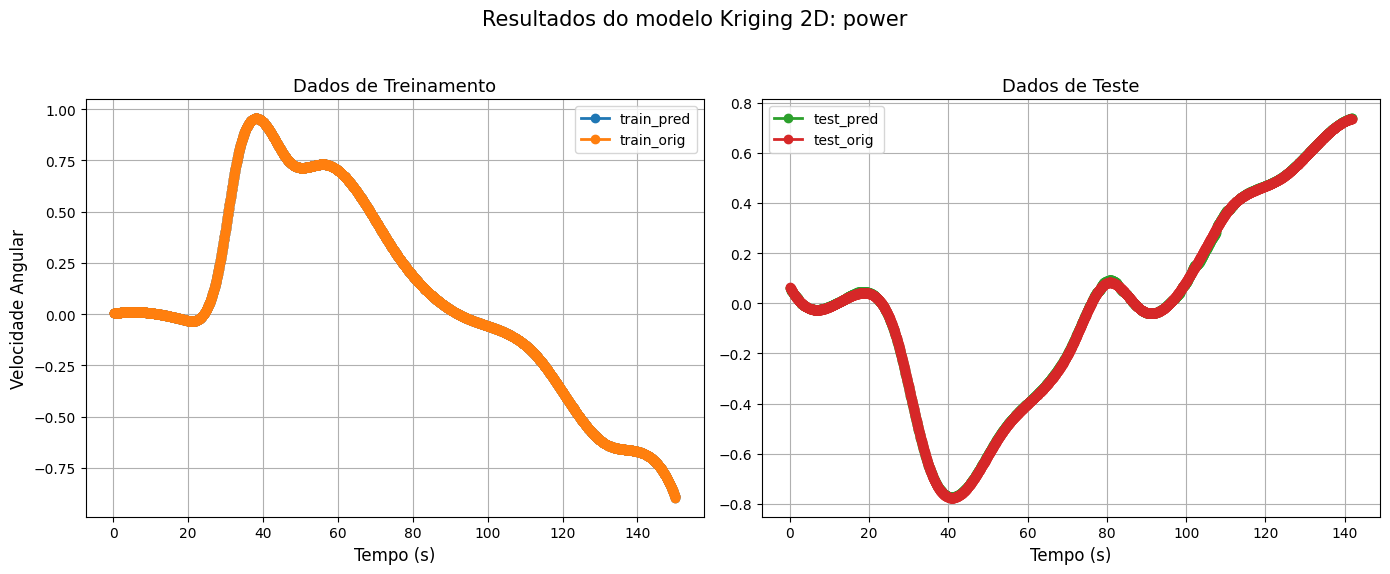

{'r2_training': 1.0,
 'mse_training': 2.212829410471568e-24,
 'mape_training': 6.88537570467651e-11,
 'rmse_training': 1.4875582040618e-12,
 'r2_test': 0.9960691934375552,
 'mse_test': 0.0006472455663374157,
 'mape_test': 0.06407074142915291,
 'rmse_test': 0.02544102133046973}

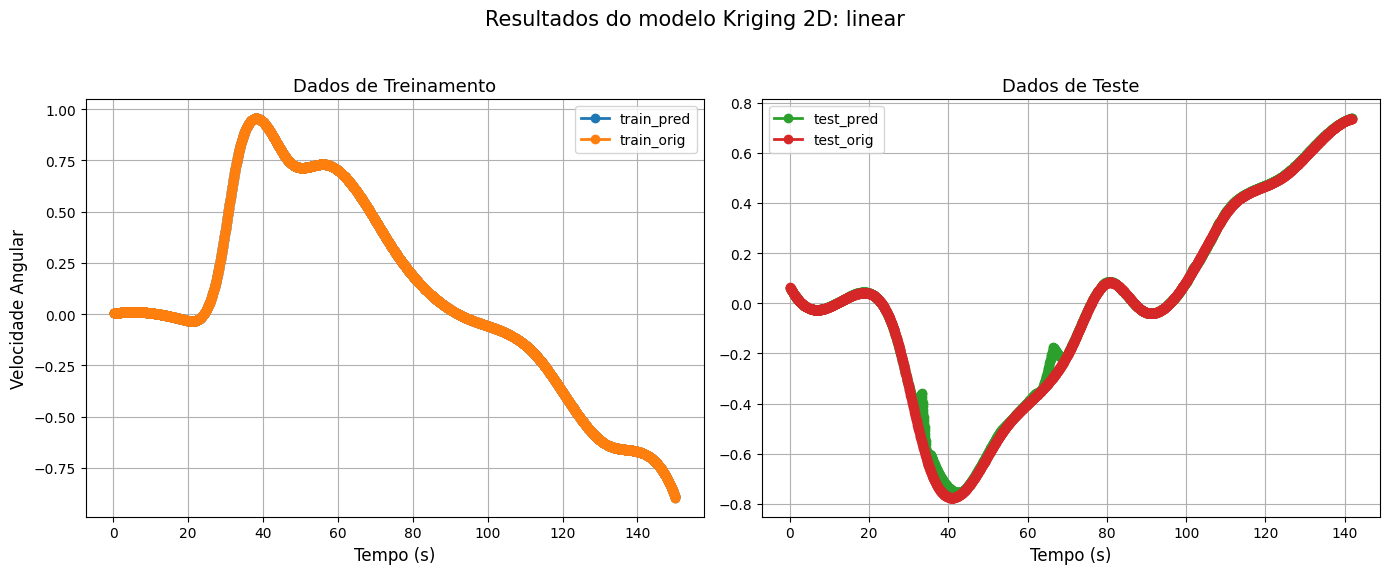

In [12]:
Vsg = Kriging2D(TrainData, TestData)        
Vsg.EvalModel("./content/KrigingMetrics.xlsx")